In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

server = r"SUFILAPTOP\SQLEXPRESS"
database = "market"
driver = quote_plus("ODBC Driver 17 for SQL Server")

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver={driver}&trusted_connection=yes"
)

print("Connected Successfully")

customers = pd.read_sql(text("SELECT * FROM [dbo].[customers]"), engine)
orders = pd.read_sql(text("SELECT * FROM [dbo].[orders]"), engine)
order_items = pd.read_sql(text("SELECT * FROM [dbo].[order_items]"), engine)
order_payments = pd.read_sql(text("SELECT * FROM [dbo].[order_payments]"), engine)
order_reviews = pd.read_sql(text("SELECT * FROM [dbo].[order_reviews]"), engine)
location = pd.read_sql(text("SELECT * FROM [dbo].[location]"), engine)
products = pd.read_sql(text("SELECT * FROM [dbo].[products]"), engine)
product_category = pd.read_sql(text("SELECT * FROM [dbo].[product_category]"), engine)
sellers = pd.read_sql(text("SELECT * FROM [dbo].[sellers]"), engine)

print("All tables imported successfully!")

tables = {
    "Customers": customers,
    "Orders": orders,
    "Order_items": order_items,
    "Order_payments": order_payments,
    "Order_reviews": order_reviews,
    "Location": location,
    "Products": products,
    "Product_category": product_category,
    "Sellers": sellers
}

for name, df in tables.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")

Connected Successfully


C:\Users\mirsu\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


All tables imported successfully!

Customers
Shape: (99441, 5)

Orders
Shape: (99441, 8)

Order_items
Shape: (112650, 7)

Order_payments
Shape: (103886, 5)

Order_reviews
Shape: (99224, 7)

Location
Shape: (1000163, 5)

Products
Shape: (32951, 9)

Product_category
Shape: (71, 2)

Sellers
Shape: (3095, 4)


# **1. Descriptive Analysis**

## **Business Objective:**

- **Understand the overall characteristics of product prices, freight costs, payment values, installment usage, and customer reviews to establish a baseline for the marketplace analysis.**

In [18]:
# required variables
descriptive_data = pd.DataFrame({
    "Price": order_items["price"],
    "Freight Value": order_items["freight_value"],
    "Payment Value": order_payments["payment_value"],
    "Installments": order_payments["payment_installments"],
    "Review Score": order_reviews["review_score"]
})

In [19]:
descriptive_stats = descriptive_data.describe().T
descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Price,112650.0,120.653739,183.633928,0.85,39.90,74.99,134.9000,6735.00
Freight Value,112650.0,19.990320,15.806405,0.00,13.08,16.26,21.1500,409.68
Payment Value,103886.0,154.100380,217.494064,0.00,56.79,100.00,171.8375,13664.08
Installments,103886.0,2.853349,2.687051,0.00,1.00,1.00,4.0000,24.00
Review Score,99224.0,4.086421,1.347579,1.00,4.00,5.00,5.0000,5.00


In [20]:
descriptive_stats[["mean", "50%", "std", "min", "max"]]

,mean,50%,std,min,max
Price,120.653739,74.99,183.633928,0.85,6735.00
Freight Value,19.990320,16.26,15.806405,0.00,409.68
Payment Value,154.100380,100.00,217.494064,0.00,13664.08
Installments,2.853349,1.00,2.687051,0.00,24.00
Review Score,4.086421,5.00,1.347579,1.00,5.00


## **Business Insight:**

- The median product price is **74.99**, compared with an average of **120.65**, indicating that product prices are right-skewed by higher-value transactions.

- The median freight value is **16.26**, while the average is **19.99**, showing that a smaller number of high-freight transactions are increasing the overall average.

- Payment value also shows substantial variation, with a median of **100.00** and an average of **154.10**. The maximum payment value of **13,664.08** indicates the presence of very high-value transactions.

- Customers use a median of **1 installment**, while the average is **2.85**, suggesting that a smaller group of orders uses significantly more installments.

- The median review score is **5**, with an average of **4.09**, indicating generally positive customer ratings, although lower-rated reviews create some variation.

# **2. Distribution Analysis:**

## **Business Objective:**

- **Understand the distribution of product prices, freight costs, and payment values to identify skewness and determine whether a small number of high-value transactions are influencing marketplace metrics.**

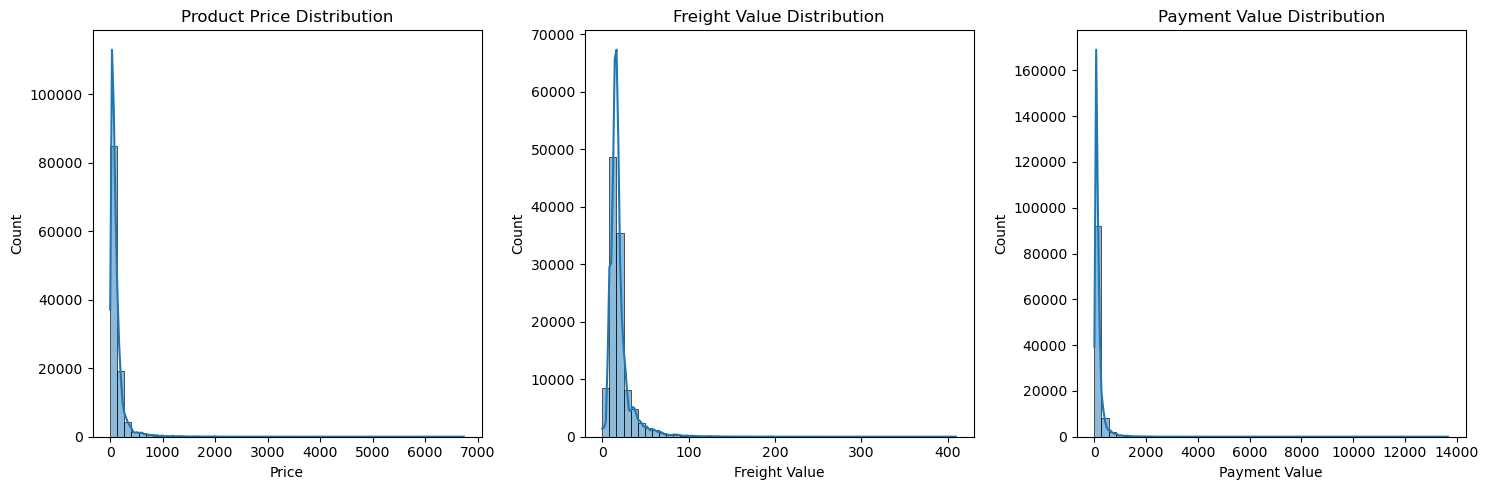

In [21]:
# Plot the distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(order_items["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Product Price Distribution")
axes[0].set_xlabel("Price")

sns.histplot(order_items["freight_value"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Freight Value Distribution")
axes[1].set_xlabel("Freight Value")

sns.histplot(order_payments["payment_value"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Payment Value Distribution")
axes[2].set_xlabel("Payment Value")

plt.tight_layout()
plt.show()

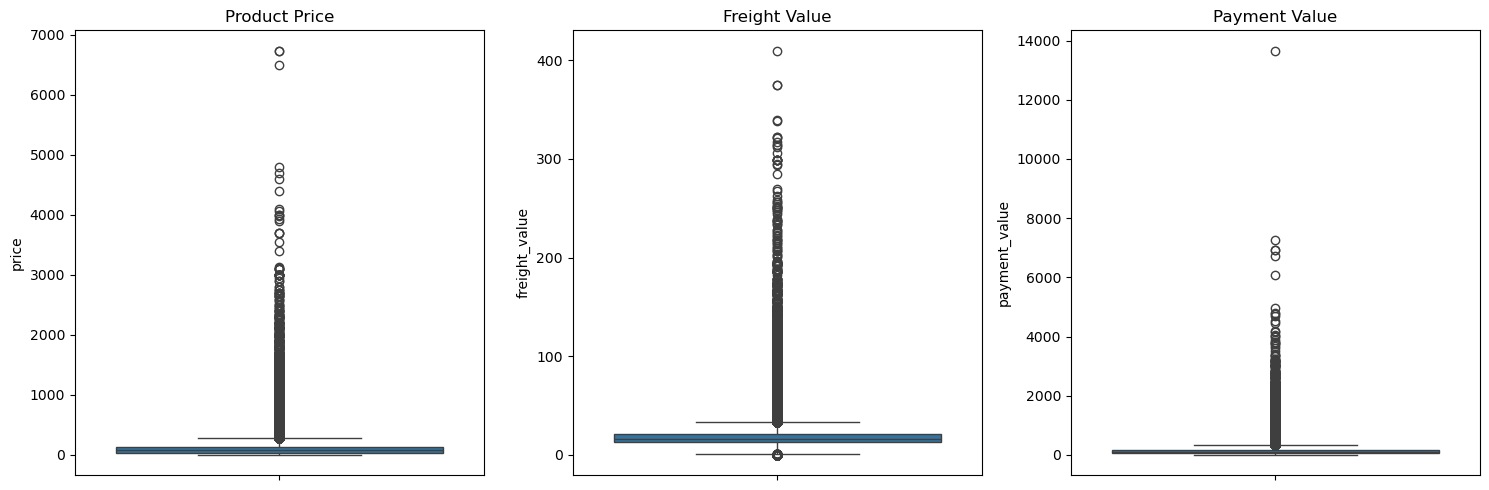

In [23]:
# boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=order_items["price"], ax=axes[0])
axes[0].set_title("Product Price")

sns.boxplot(y=order_items["freight_value"], ax=axes[1])
axes[1].set_title("Freight Value")

sns.boxplot(y=order_payments["payment_value"], ax=axes[2])
axes[2].set_title("Payment Value")

plt.tight_layout()
plt.show()

## **Business Insight:**

- Product prices, freight values, and payment values are strongly right-skewed. Most transactions fall within relatively low ranges, while a small number of high-value transactions extend the distributions considerably.

- The boxplots also show a large number of observations beyond the upper quartile, particularly for product price and payment value. These extreme observations should not automatically be removed because they may represent genuine high-value transactions.

- This confirms that the marketplace averages are being influenced by a smaller number of high-value transactions, so median values and outlier analysis should be considered alongside the mean when evaluating business performance.

# **3. Outlier Analysis:**

## **Business Objective:**

- **Identify unusually high product prices, freight costs, and payment values that may create financial or logistics risk for the marketplace.**

In [24]:
# outliers
def find_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return lower, upper, len(outliers)

for column, data in [
    ("Price", order_items),
    ("Freight Value", order_items),
    ("Payment Value", order_payments)
]:
    lower, upper, count = find_outliers(
        data,
        column.lower().replace(" ", "_")
    )
    print(column)
    print("Lower limit:", round(lower, 2))
    print("Upper limit:", round(upper, 2))
    print("Outliers:", count)
    print()

Price
Lower limit: -102.6
Upper limit: 277.4
Outliers: 8427

Freight Value
Lower limit: 0.98
Upper limit: 33.25
Outliers: 12134

Payment Value
Lower limit: -115.78
Upper limit: 344.41
Outliers: 7981



In [25]:
print("Top 10 Product Prices")
print(order_items.nlargest(10, "price")[["order_id", "product_id", "seller_id", "price"]])

Top 10 Product Prices
                                order_id                        product_id  \
3556    0812eb902a67711a1cb742b3cdaa65ae  489ae2aa008f021502940f251d4cce7f   
112233  fefacc66af859508bf1a7934eab1e97f  69c590f7ffc7bf8db97190b6cb6ed62e   
107841  f5136e38d1a14a4dbd87dff67da82701  1bdf5e6731585cf01aa8169c7028d6ad   
74336   a96610ab360d42a2e5335a3998b4718a  a6492cc69376c469ab6f61d8f44de961   
11249   199af31afc78c699f0dbf71fb178d4d4  c3ed642d592594bb648ff4a04cee2747   
62086   8dbc85d1447242f3b127dda390d56e19  259037a6a41845e455183f89c5035f18   
29193   426a9742b533fc6fed17d1fd6d143d7e  a1beef8f3992dbd4cd8726796aa69c53   
45843   68101694e5c5dc7330c91e1bbc36214f  6cdf8fc1d741c76586d8b6b15e9eef30   
78310   b239ca7cd485940b31882363b52e6674  dd113cb02b2af9c8e5787e8f1f0722f6   
59137   86c4eab1571921a6a6e248ed312f5a5a  6902c1962dd19d540807d0ab8fade5c6   

                               seller_id    price  
3556    e3b4998c7a498169dc7bce44e6bb6277  6735.00  
112233  80ceebb

In [26]:
print("Top 10 Freight Values")
print(order_items.nlargest(10, "freight_value")[["order_id", "product_id", "seller_id", "freight_value"]])

Top 10 Freight Values
                               order_id                        product_id  \
73486  a77e1550db865202c56b19ddc6dc4d53  ec31d2a17b299511e7c8627be9337b9b   
3303   076d1555fb53a89b0ef4d529e527a0f6  a3cd9517ebf5a50dca25acce54f3b171   
28044  3fde74c28a3d5d618c00f26d51baafa0  a3cd9517ebf5a50dca25acce54f3b171   
69797  9f49bd16053df810384e793386312674  256a9c364b75753b97bee410c9491ad8   
16731  264a7e199467906c0727394df82d1a6a  97c948ebc8c04b26b7bbb095d4228f2a   
87936  c7a07ddd52bbe18b61da49a8d89853d3  97c948ebc8c04b26b7bbb095d4228f2a   
5037   0b6230647ed16f4b3e70282dc4b5b87f  46e24ce614899e36617e37ea1e4aa6ff   
3584   0822bcde10bb5d023755a71bc8f7797f  363a9f5b97bf194da23858be722a7aa5   
29787  43bdbd9dc0931d72befdf4765af6c442  7e53e051875b2a0c9f22acd8a9a29a20   
48320  6ddfbf514959b49b6410c01ad93054bb  363a9f5b97bf194da23858be722a7aa5   

                              seller_id  freight_value  
73486  257e61d3251fb5efb9daadddbc2cf7ca         409.68  
3303   6fa9202c1

In [27]:
print("Top 10 Payment Values")
print(order_payments.nlargest(10, "payment_value")[["order_id", "payment_type", "payment_value"]])

Top 10 Payment Values
                               order_id payment_type  payment_value
52107  03caa2c082116e1d31e67e9ae3700499  credit_card       13664.08
34370  736e1922ae60d0d6a89247b851902527       boleto        7274.88
41419  0812eb902a67711a1cb742b3cdaa65ae  credit_card        6929.31
49581  fefacc66af859508bf1a7934eab1e97f       boleto        6922.21
85539  f5136e38d1a14a4dbd87dff67da82701       boleto        6726.66
62409  2cc9089445046817a7539d90805e6e5a       boleto        6081.54
43232  a96610ab360d42a2e5335a3998b4718a  credit_card        4950.34
70320  b4c4b76c642808cbe472a32b86cddc95  credit_card        4809.44
6440   199af31afc78c699f0dbf71fb178d4d4  credit_card        4764.34
67546  8dbc85d1447242f3b127dda390d56e19  credit_card        4681.78


## **Business Insight:**

- The IQR analysis identifies **8,427 price outliers**, **12,134 freight-value outliers**, and **7,981 payment-value outliers**.

- The upper thresholds are **277.40** for price, **33.25** for freight value, and **344.41** for payment value. This shows that a relatively small portion of transactions has substantially higher values than the typical marketplace transaction.

- The extreme values appear to be legitimate transactions rather than obvious data-entry errors. For example, the highest product price is **6,735.00**, the highest freight value is **409.68**, and the highest payment value is **13,664.08**.

- These observations should therefore be retained. However, they can materially influence averages and should be considered separately when evaluating pricing, freight efficiency, and payment exposure.

# **4. Correlation Analysis:**

## **Business Objective:**

- **Measure the strength and direction of relationships between product price, freight cost, payment value, and installment usage to identify potential drivers of marketplace costs and payment behavior.**

In [28]:
# correlation dataset
correlation_data = pd.DataFrame({
    "Price": order_items["price"],
    "Freight Value": order_items["freight_value"]
}).dropna()

In [33]:
# For payment and installments
payment_correlation = order_payments[
    ["payment_value", "payment_installments"]
].dropna()

In [34]:
# Calculate correlations
print("Price vs Freight:", round(
    correlation_data["Price"].corr(correlation_data["Freight Value"]), 3
))

print("Payment Value vs Installments:", round(
    payment_correlation["payment_value"].corr(
        payment_correlation["payment_installments"]
    ), 3
))

Price vs Freight: 0.414
Payment Value vs Installments: 0.331


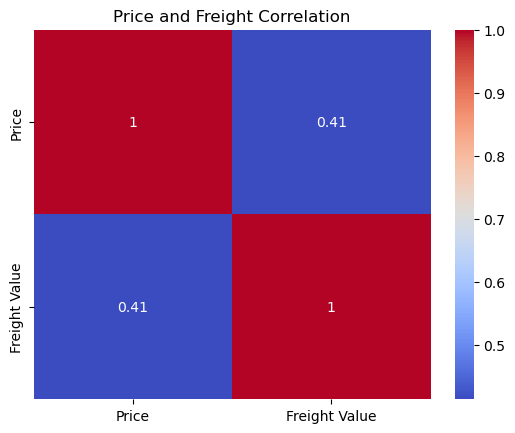

In [35]:
# Correlation heatmap
corr = pd.DataFrame({
    "Price": order_items["price"],
    "Freight Value": order_items["freight_value"]
}).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Price and Freight Correlation")
plt.show()

## **Business Insight:**

- Price and freight value have a correlation of **0.414**, indicating a **moderate positive relationship**. Higher-priced products generally tend to have higher freight costs, but price alone does not fully explain freight variation.

- Payment value and installment count have a correlation of **0.331**, indicating a **weak-to-moderate positive relationship**. Higher-value payments tend to use more installments, but other factors also influence installment usage.

- These relationships suggest that both product value and transaction value are relevant factors in freight and payment behavior, but neither relationship is strong enough to be treated as the sole driver.

# **5. Confidence Interval Analysis**

## **Business Objective:**

- **Estimate the likely range of the true average freight cost and payment value using 95% confidence intervals, providing a more reliable benchmark than relying on a single sample mean.**

In [36]:
# Calculate 95% confidence intervals
from scipy.stats import sem, t

def confidence_interval(data):
    data = data.dropna()
    mean = data.mean()
    margin = t.ppf(0.975, len(data)-1) * sem(data)
    return mean, mean-margin, mean+margin

freight_ci = confidence_interval(order_items["freight_value"])
payment_ci = confidence_interval(order_payments["payment_value"])

print("Freight Value")
print("Mean:", round(freight_ci[0], 2))
print("95% CI:", round(freight_ci[1], 2), "to", round(freight_ci[2], 2))

print("\nPayment Value")
print("Mean:", round(payment_ci[0], 2))
print("95% CI:", round(payment_ci[1], 2), "to", round(payment_ci[2], 2))

Freight Value
Mean: 19.99
95% CI: 19.9 to 20.08

Payment Value
Mean: 154.1
95% CI: 152.78 to 155.42


## **Business Insight:**

- The estimated average freight value is **19.99**, with a 95% confidence interval of **19.90 to 20.08**.

- The estimated average payment value is **154.10**, with a 95% confidence interval of **152.78 to 155.42**.

- Both intervals are relatively narrow, indicating that the large number of transactions provides a stable estimate of the marketplace's average freight and payment values.

- These averages can therefore be used as reliable baseline benchmarks when evaluating future changes in freight costs and transaction values.

# **6. Time Series Forecasting**

In [43]:
# Prepare monthly revenue
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

monthly_revenue = orders.merge(
    order_items[["order_id", "price"]],
    on="order_id"
)

monthly_revenue["month"] = monthly_revenue[
    "order_purchase_timestamp"
].dt.to_period("M")

monthly_revenue = monthly_revenue.groupby(
    "month"
)["price"].sum().reset_index()

monthly_revenue["month"] = monthly_revenue["month"].dt.to_timestamp()

monthly_revenue.head()

Forecasted Revenue for Next Month: 871772.62


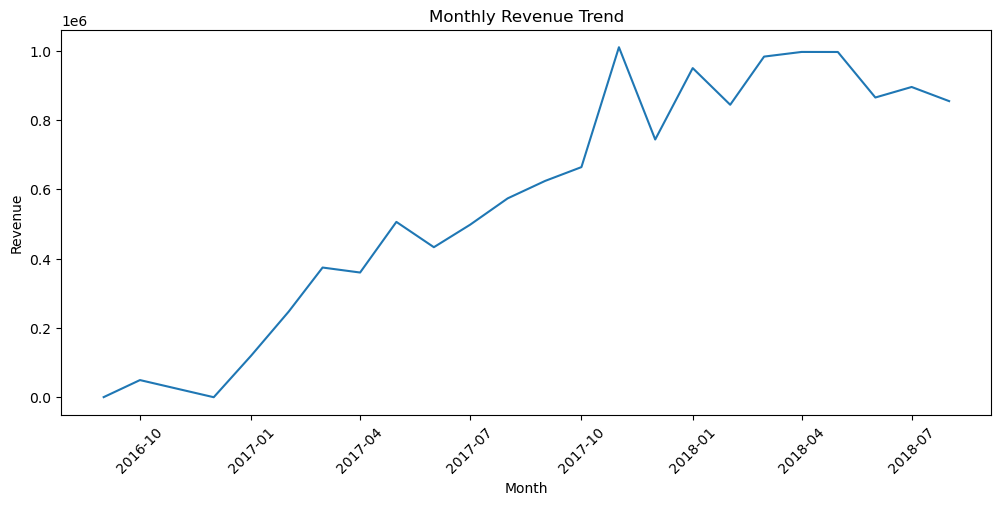

In [44]:
# Plot the monthly trend
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="price"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [40]:
# 3 months avg
monthly_revenue["forecast"] = monthly_revenue["price"].rolling(3).mean()

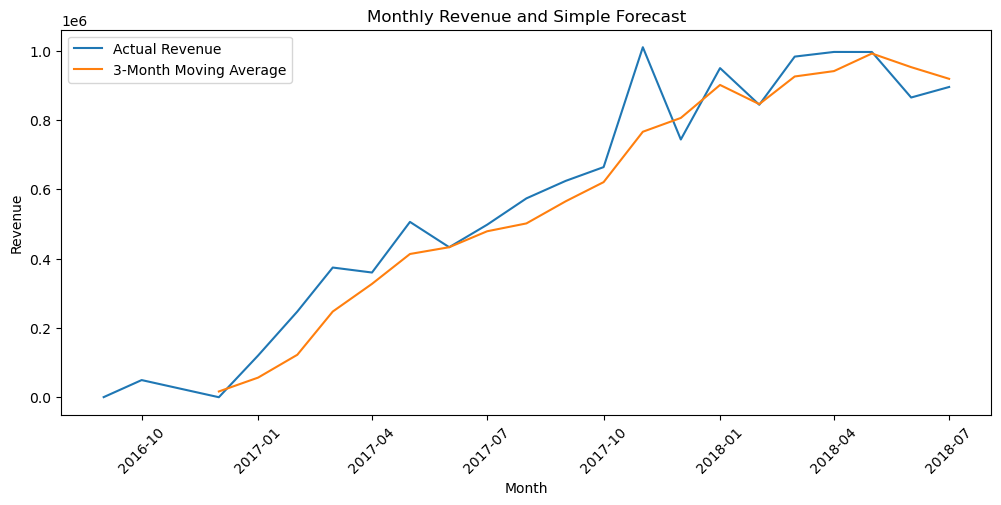

In [47]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["price"],
    label="Actual Revenue"
)

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["forecast"],
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue and Simple Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [48]:
# Forecast the next month
monthly_revenue = monthly_revenue[
    monthly_revenue["month"] < monthly_revenue["month"].max()
].copy()

monthly_revenue["forecast"] = monthly_revenue["price"].rolling(3).mean()

next_month_forecast = monthly_revenue["price"].tail(3).mean()

print("Forecasted Revenue for Next Month:", round(next_month_forecast, 2))

Forecasted Revenue for Next Month: 952763.25


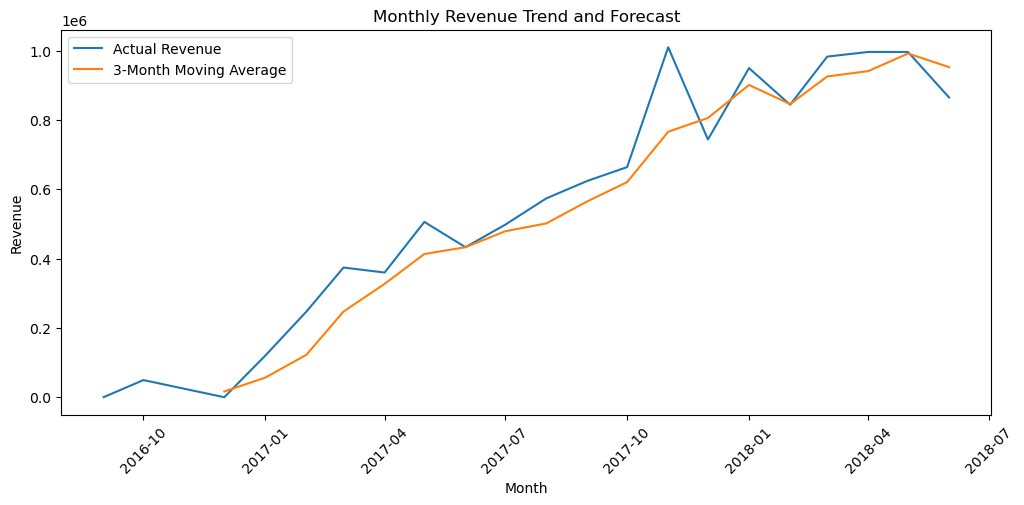

In [49]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["price"],
    label="Actual Revenue"
)

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["forecast"],
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue Trend and Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## **Business Insight:**

- Marketplace revenue shows a strong upward trend from late 2016 through 2017, followed by a period of relatively stable performance at a higher revenue level during 2018.

- The 3-month moving average follows the overall revenue trend reasonably well and smooths short-term fluctuations. However, the final observed month appears incomplete and was excluded from the forecast to avoid understating the expected revenue.

- The corrected moving-average forecast provides a simple short-term benchmark for expected revenue and can be used to compare future marketplace performance against the recent trend.

# Key Statistical Findings

## 1. Descriptive Analysis

- The median product price is **74.99**, while the mean is **120.65**, indicating that high-value products are pulling the average upward.
- The median freight value is **16.26**, compared with a mean of **19.99**, showing that higher freight transactions are increasing the average.
- Payment value has a median of **100.00** and a mean of **154.10**, indicating substantial variation in transaction values.
- Customers use a median of **1 installment**, while the average is **2.85**, showing that a smaller group of transactions uses significantly more installments.
- The median review score is **5**, with an average of **4.09**, indicating generally positive customer ratings.

## 2. Distribution Analysis

- Product price, freight value, and payment value are all **strongly right-skewed**.
- Most transactions are concentrated at relatively low values, while a smaller number of high-value transactions create long right tails.
- This means that the **median is often more representative of a typical transaction than the mean**.
- The distributions also indicate that high-value transactions need to be considered separately when evaluating marketplace performance.

## 3. Outlier Analysis

- The IQR method identified **8,427 price outliers**, **12,134 freight-value outliers**, and **7,981 payment-value outliers**.
- The upper IQR thresholds were **277.40 for price**, **33.25 for freight value**, and **344.41 for payment value**.
- The highest observed product price was **6,735.00**, while the highest freight value was **409.68**.
- The highest payment value was **13,664.08**.
- These extreme observations appear to represent legitimate high-value transactions rather than obvious data errors, so they were **retained rather than removed**.
- The presence of these outliers means that average-based business metrics should be interpreted together with median values.

## 4. Correlation Analysis

- Product price and freight value have a correlation of **0.414**, indicating a **moderate positive relationship**.
- Payment value and installment count have a correlation of **0.331**, indicating a **weak-to-moderate positive relationship**.
- Higher-priced products generally tend to have higher freight costs, but price alone does not explain freight variation.
- Higher-value payments tend to be associated with more installments, but installment behavior is influenced by other factors as well.
- These relationships indicate association, **not causation**.

## 5. Confidence Interval Analysis

- The estimated mean freight value is **19.99**, with a 95% confidence interval of **19.90 to 20.08**.
- The estimated mean payment value is **154.10**, with a 95% confidence interval of **152.78 to 155.42**.
- Both confidence intervals are relatively narrow because of the large number of transactions in the dataset.
- The results provide stable benchmarks for the marketplace's average freight cost and payment value.

## 6. Time Series Forecasting

- Monthly marketplace revenue shows a **strong upward trend** from late 2016 through 2017.
- Revenue reached a significantly higher and relatively stable level during 2018 compared with the beginning of the dataset.
- A 3-month moving average effectively smooths short-term fluctuations and follows the overall revenue trend.
- The final observed month appears incomplete and was therefore excluded from the forecasting calculation to avoid distorting the estimate.
- The 3-month moving average provides a simple short-term revenue benchmark for comparing future marketplace performance.

## Overall Statistical Conclusion

The statistical analysis shows that the marketplace is characterized by **right-skewed transaction values, significant high-value outliers, moderate price-freight association, and a positive relationship between payment value and installment usage**.

Freight and payment metrics should therefore be evaluated using both average and median values, while extreme transactions should be monitored rather than automatically removed.

The analysis also shows that the marketplace experienced substantial revenue growth over the observed period, providing a useful baseline for evaluating future performance.